# Task 2: Transfer Learning using VGG16 / ResNet50**Objective:** Implement transfer learning using a pre-trained deep learning model (ResNet50) and analyze the performance improvement over a custom (baseline) CNN architecture, on the Flowers Recognition dataset.**Dataset used:** Flowers Recognition Dataset (Kaggle: `alxmamaev/flowers-recognition`) — 5 classes (daisy, dandelion, rose, sunflower, tulip), 4317 images total.**Approach:**1. Load and preprocess the Flowers Recognition dataset.2. Build and train a baseline custom CNN from scratch.3. Load a pretrained ResNet50 (ImageNet weights), freeze the base layers, and fine-tune a custom classification head on top (transfer learning).4. Compare training time, validation accuracy, and validation loss between the two models.5. Visualize accuracy/loss curves and summarize results and observations.

In [1]:
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers

## 1. Dataset AcquisitionThe Flowers Recognition dataset is downloaded directly from Kaggle using `kagglehub`.

In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
print("Path to dataset files:", path)

100%|██████████| 225M/225M [00:12<00:00, 19.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2


In [4]:
dataset_dir = os.path.join(path, "flowers") if os.path.exists(os.path.join(path, "flowers")) else path

## 2. Data Loading and Preprocessing- Images are resized to `180x180` and loaded in batches of 32 using `image_dataset_from_directory`.- An 80/20 train-validation split is used.- Pixel values are rescaled to the `[0, 1]` range.- A data augmentation pipeline (random horizontal flip, rotation, zoom) is defined and applied inside both models to reduce overfitting.

In [5]:
# 2.Data loading and Pre Processing
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

# Load train and validation splits using image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found ({num_classes}): {class_names}")

# Performance optimization: Prefetching & Data Rescaling Layer
rescale_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (rescale_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# Data Augmentation Pipeline
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="data_augmentation")

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Classes found (5): ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


## 3. Baseline CNN Model (Custom Architecture)A simple custom CNN is built from scratch (3 convolutional blocks + dense classifier) to serve as the baseline for comparison against the transfer learning model.

In [6]:

def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(180, 180, 3)),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name="Baseline_CNN")

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## 4. Transfer Learning Model (ResNet50)A pretrained **ResNet50** (ImageNet weights, top classification layers excluded) is used as a frozen feature extractor. A new classification head (Global Average Pooling → BatchNorm → Dense(256) → Dropout → Dense(softmax)) is added and trained on the flowers dataset, while the base ResNet50 layers remain frozen.

In [7]:
def build_transfer_learning_resnet():
    # Load base model with ImageNet weights (excluding top classification head)
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(180, 180, 3)
    )

    # Freeze base feature extractor
    base_model.trainable = False

    inputs = layers.Input(shape=(180, 180, 3))
    x = data_augmentation(inputs)
    # Scaled back to [0, 255] for ResNet internal preprocessing requirement
    x = applications.resnet.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="ResNet50_TransferLearning")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


## 5. Model TrainingBoth the baseline CNN and the ResNet50 transfer learning model are trained for 10 epochs on the same train/validation split, and the training time for each is recorded for comparison.

In [8]:
EPOCHS = 10

# Train Custom Baseline CNN
print("\n" + "="*50)
print(" Training Baseline Custom CNN ")
print("="*50)
baseline_cnn = build_baseline_cnn()
start_cnn = time.time()
history_cnn = baseline_cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_cnn = time.time() - start_cnn

# Train ResNet50 Transfer Learning Model
print("\n" + "="*50)
print(" Training ResNet50 Transfer Learning Model ")
print("="*50)
resnet_tl = build_transfer_learning_resnet()
start_tl = time.time()
history_tl = resnet_tl.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
time_tl = time.time() - start_tl



 Training Baseline Custom CNN 
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.4218 - loss: 1.3161 - val_accuracy: 0.5632 - val_loss: 1.0848
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.5388 - loss: 1.1379 - val_accuracy: 0.6118 - val_loss: 0.9819
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.5860 - loss: 1.0372 - val_accuracy: 0.6385 - val_loss: 0.9629
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.6190 - loss: 0.9776 - val_accuracy: 0.6628 - val_loss: 0.8759
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6265 - loss: 0.9481 - val_accuracy: 0.6756 - val_loss: 0.8459
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6584 - loss: 0.9004 - val_accuracy: 0.6767 - val_loss: 0.8175
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.6824 - loss: 0.8567 - val_accuracy: 0.6976 - val_loss: 0.7811
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accura

## 6. Accuracy & Loss VisualizationValidation accuracy and validation loss curves for both models are plotted side-by-side for direct comparison.**[SCREENSHOT PLACEHOLDER: Accuracy & Loss comparison plot]**

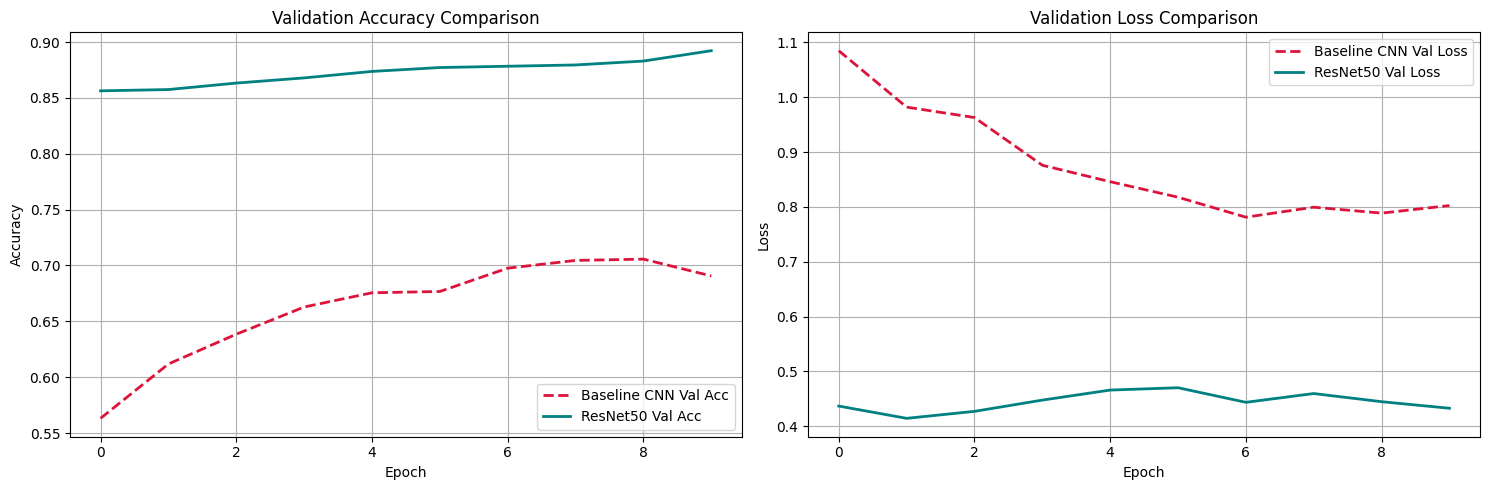

In [9]:
# 6. Accuracy & Loss Visualization Plots

plt.figure(figsize=(15, 5))

# Validation Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['val_accuracy'], label='Baseline CNN Val Acc', color='crimson', linestyle='--', linewidth=2)
plt.plot(history_tl.history['val_accuracy'], label='ResNet50 Val Acc', color='teal', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Validation Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['val_loss'], label='Baseline CNN Val Loss', color='crimson', linestyle='--', linewidth=2)
plt.plot(history_tl.history['val_loss'], label='ResNet50 Val Loss', color='teal', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Performance Summary TableA summary table comparing best validation accuracy, lowest validation loss, and total training time for the baseline CNN vs. the ResNet50 transfer learning model.

In [10]:
# 7. Print Performance Summary Table

val_acc_cnn = max(history_cnn.history['val_accuracy']) * 100
val_acc_tl = max(history_tl.history['val_accuracy']) * 100
val_loss_cnn = min(history_cnn.history['val_loss'])
val_loss_tl = min(history_tl.history['val_loss'])

print("\n" + "="*60)
print(f"{'Metric':<25} | {'Baseline CNN':<15} | {'ResNet50 TL':<15}")
print("="*60)
print(f"{'Best Val Accuracy (%)':<25} | {val_acc_cnn:<15.2f} | {val_acc_tl:<15.2f}")
print(f"{'Lowest Val Loss':<25} | {val_loss_cnn:<15.4f} | {val_loss_tl:<15.4f}")
print(f"{'Total Time (seconds)':<25} | {time_cnn:<15.2f} | {time_tl:<15.2f}")
print("="*60)


Metric                    | Baseline CNN    | ResNet50 TL    
Best Val Accuracy (%)     | 70.57           | 89.22          
Lowest Val Loss           | 0.7811          | 0.4143         
Total Time (seconds)      | 81.09           | 143.83         


## 8. Results and Observations### Results| Metric | Baseline CNN | ResNet50 (Transfer Learning) ||---|---|---|| Best Validation Accuracy | 70.57% | **89.22%** || Lowest Validation Loss | 0.7811 | **0.4143** || Total Training Time (10 epochs) | 81.09 s | 143.83 s || Validation Accuracy (Epoch 1) | 56.32% | 85.63% |### Observations1. **Accuracy improvement:** The ResNet50 transfer learning model achieved a best validation accuracy of **89.22%**, an improvement of roughly **18.65 percentage points** over the baseline CNN's **70.57%**. This confirms that features learned from ImageNet transfer effectively to the flower classification task.2. **Faster convergence:** The transfer learning model reached **85.63% validation accuracy in just the first epoch**, a level the baseline CNN never reached even after 10 full epochs. This shows that the pretrained convolutional filters (edges, textures, shapes) already encode useful representations for this task, drastically reducing the number of epochs needed to converge.3. **Lower and more stable loss:** The final validation loss for the transfer learning model (0.4143) is less than half that of the baseline CNN (0.7811), indicating more confident and better-calibrated predictions.4. **Baseline CNN limitations:** Training from scratch on a relatively small dataset (~3454 training images) causes the baseline CNN to plateau around 70% accuracy. With only 3 convolutional blocks and no pretrained knowledge, it struggles to learn generalizable features from a limited number of samples, and its validation accuracy/loss curve is noisier (e.g., val_loss increases slightly in epoch 8 before recovering).5. **Training time trade-off:** The transfer learning model takes about **1.77x longer per run** (143.83s vs 81.09s for 10 epochs) mainly due to the larger ResNet50 backbone performing a forward pass on every batch, even though its weights are frozen. However, given the large accuracy gain and faster convergence, far fewer epochs would be needed in practice to reach a comparable or better accuracy than the baseline, making transfer learning more time-efficient overall for reaching a target accuracy.6. **Overfitting behavior:** The transfer learning model's training accuracy (93.69% by epoch 10) is closer to its validation accuracy (89.22%) than might be expected for a small dataset, showing that freezing the base layers and using dropout (0.4) plus data augmentation effectively controlled overfitting.### ConclusionTransfer learning with a pretrained ResNet50 clearly outperforms a custom CNN trained from scratch on the Flowers Recognition dataset — delivering higher accuracy, lower loss, and dramatically faster convergence, at the cost of a moderate increase in per-epoch training time. For small-to-medium sized image classification datasets, transfer learning is the more effective and practical approach compared to training a CNN from scratch.